##  Learning Outcomes

After this video, you'll be able to:

<ul>
    <li>Build linear regression models using scikit-learn</li>
    <li>Evaluate model performance using RMSE and R²</li>
</ul>

## Setup and Data Preparation

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load the preprocessed dataset
df = pd.read_csv('insightlysoft_dataset.csv')
df.head()

,account_id,monthly_login_freq,num_support_tickets,contract_length_months,avg_product_usage_hours,num_users,nps_score,has_admin_activity,last_activity_days_ago,avg_session_length,feature_adoption_score,customer_satisfaction_score,city,gender,churned,is_heavy_user
0,A0001,21,5.0,6,28.16,58,6.390714,0,5,1.51,89.98,8.42,Chicago,Female,0,1
1,A0002,13,5.0,6,18.70,33,0.792736,1,20,1.33,11.82,1.33,New York,Female,1,0
2,A0003,23,5.0,6,32.73,61,5.267689,0,2,0.48,31.07,6.60,Austin,Female,0,1
3,A0004,25,5.0,6,9.25,4,5.548030,0,34,2.04,77.84,5.75,Chicago,Male,1,1
4,A0005,16,18.0,24,29.08,99,-0.017153,0,4,1.92,54.32,0.31,Austin,Female,0,1


## Introduction to Linear Regression

### y = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ

Where:

- y is the predicted value (for example, the monthly login frequency),


- x₁ to xₙ are the input features (like nps scores or number of support tickets,


- and β₀ to βₙ are the coefficients that the model learns.

## Feature Scaling for Linear Regression

In [2]:
y = df['customer_satisfaction_score']

X = df[['monthly_login_freq', 'num_support_tickets', 'avg_product_usage_hours',
        'num_users', 'nps_score', 'feature_adoption_score']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Building

In [4]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

## Model Evaluation

RMSE: 1.25
R² Score: 0.80

monthly_login_freq: -0.0178
num_support_tickets: -0.0218
avg_product_usage_hours: -0.0010
num_users: -0.0017
nps_score: 1.1606
feature_adoption_score: -0.0019


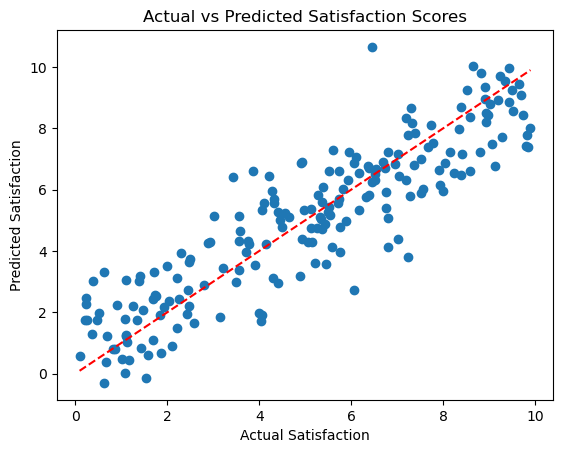

In [5]:
# Print metrics and coefficients
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}\n")

features = ['monthly_login_freq', 'num_support_tickets', 'avg_product_usage_hours',
            'num_users', 'nps_score', 'feature_adoption_score']
# Display feature importance
for feature, coef in zip(features, model.coef_):
    print(f"{feature}: {coef:.4f}")

# Visualize actual vs predicted
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Satisfaction')
plt.ylabel('Predicted Satisfaction')
plt.title('Actual vs Predicted Satisfaction Scores')
plt.show()


## Recap


In this video, we covered:

- Building linear regression models with scikit-learn 

- Selecting and preparing features for prediction 

- Evaluating model performance with key metrics 

- Translating technical results into business insights